# Importing Data

In [1]:
import numpy as np
import pandas as pd

# Get Challenge 2015 dataset
with_ppg=[]
import os
for dirname, _, filenames in os.walk('/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/'):
    for filename in filenames:
        if(filename!="ALARMS"):
            if("PLETH" in pd.read_csv(dirname+filename).columns):
                with_ppg.append(filename[0:-4])

# Remove samples with asystole
df=pd.read_csv("/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/ALARMS", names=["Sample", "Label", "TrueAlarm"])
df_relevant=df.loc[df["Label"]!="Asystole"].copy()

# Only include samples with PPG
df_filtered=df_relevant.loc[df_relevant["Sample"].isin(with_ppg)].copy()

# Add path column
df_filtered["Path"]=["/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/"+x+".csv" for x in df_filtered["Sample"]]



In [2]:
# For downsampling 250 Hz to 125 Hz for consistency
def downsample(signal_in, original_fs=250, target_fs=125):
    if original_fs == target_fs:
        return signal_in  # No downsampling needed
    
    # Design a low-pass filter (FIR or IIR)
    nyquist = target_fs / 2  # Nyquist frequency for new sampling rate
    b, a = signal.butter(4, nyquist / (original_fs / 2), btype='low', analog=False)

    # Apply filter
    filtered_signal = signal.filtfilt(b, a, signal_in)

    # Downsample (take every 2nd sample)
    downsampled_signal = filtered_signal[::2]

    return downsampled_signal

In [3]:
afib_paths=[]
healthy_paths=[]
afib_samples=[]
healthy_samples=[]

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_af_csv/mimic_perform_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            afib_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            afib_samples.append(filename_split[2]+"_"+filename_split[3])

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_non_af_csv/mimic_perform_non_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            healthy_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            healthy_samples.append(filename_split[2]+"_"+filename_split[3]+"_"+filename_split[4])

afib_df=pd.DataFrame({"Sample":afib_samples,
        "Label":19*["Atrial_Fibrillation"],
        "TrueAlarm":19*[True],
        "Path":afib_paths})

healthy_df=pd.DataFrame({"Sample":healthy_samples,
        "Label":16*["Healthy"],
        "TrueAlarm":16*[True],
        "Path":healthy_paths})

df_filtered=pd.concat([df_filtered, afib_df, healthy_df])

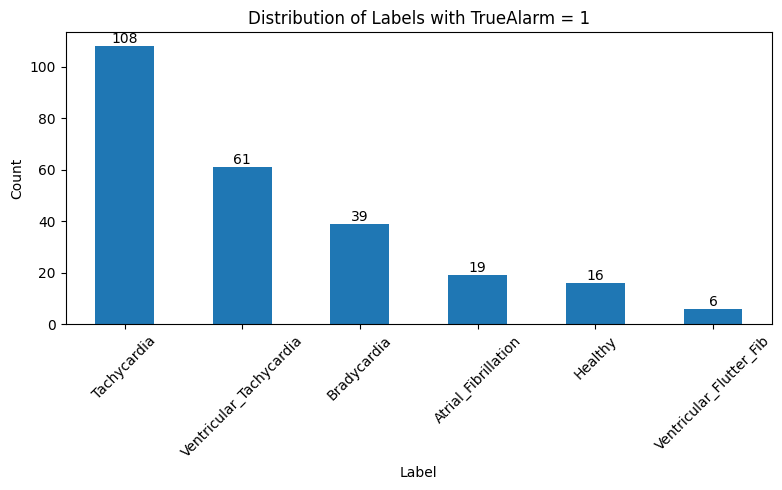

In [4]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df_filtered.loc[df_filtered["TrueAlarm"] == 1, "Label"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels with TrueAlarm = 1")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


In [5]:
import scipy.signal as signal

# For downsampling 250 Hz to 125 Hz for consistency
def downsample(ecg_signal, original_fs=250, target_fs=125):
    if original_fs == target_fs:
        return ecg_signal  # No downsampling needed
    
    # Design a low-pass filter (FIR or IIR)
    nyquist = target_fs / 2  # Nyquist frequency for new sampling rate
    b, a = signal.butter(4, nyquist / (original_fs / 2), btype='low', analog=False)

    # Apply filter
    filtered_signal = signal.filtfilt(b, a, ecg_signal)

    # Downsample (take every 2nd sample)
    downsampled_signal = filtered_signal[::2]

    return downsampled_signal

def standardize(data):
    return ( data - np.mean(data) ) / (np.std(data)+1e-8)

def getWaveform(label, index, sampleType, startPoint=0, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        return_signal=pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+int(duration/2)]
        pass
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+duration]
        except:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values[startPoint:startPoint+duration]
        
        return_signal=downsample(return_signal)
    return standardize(return_signal)

def getWaveforms(label, index, sampleType, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        fullWaveform = standardize(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values)
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            fullWaveform = standardize(downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values))
        except:
            fullWaveform = standardize(downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values))
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    return periodsList

def get_num_waves(label, trueAlarm=1):
    return len(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm)].index)

# Feature Extraction

In [39]:
def get_diastolic_time(ppg_valleys):
    return calc_median_distance(ppg_valleys)
    
def get_rr_std(ecg_peaks):
    return calc_std_distance(ecg_peaks)
    
def get_rr_median(ecg_peaks):
    return calc_median_distance(ecg_peaks)
#def trapezoidal
def calc_median_distance(points):
    size=len(points)
    if(size<2):
        return 0
    distances=[]
    for i in range(size-1):
        distances.append(points[i+1]-points[i])

    return np.median(distances)
    '''if((size-1)%2==0):
        return float(distances[int((size - 1) / 2)] + distances[int(((size - 1) / 2) + 1)]) / 2
    else:
        return float(distances[int((size - 1) / 2)])'''
    
def calc_std_distance(points):
    size=len(points)
    if(size<2):
        return 0
    distances=[]
    for i in range(size-1):
        distances.append(float(points[i+1]-points[i]))
    return np.std(distances)

def find_peaks_noor(x, min_val, distance, prominence, width):
    size=len(x)
    peak_count=0
    peaks=[]
    ctr=0
    for i in range(size):
        if(i==0):
            continue
        if(i==size-1):
            continue
        if(x[i]<min_val):
            continue
        if(i>0 and x[i-1]>x[i]):
            continue
        if(i<size-1 and x[i+1]>x[i]):
            continue
        if(width>0):
            if(i>np.floor(width/2) and i<size-1-np.floor(width/2)):
                local_max=0
                for j in range(int(i - np.floor(width / 2)), int(i + np.floor(width / 2) + 1)):
                    if(x[j]>local_max):
                        local_max=x[j]
                if(x[i]!=local_max):
                    continue

        # Clustering
        if(distance>0):
            if(peak_count>0 and i-peaks[peak_count-1]<distance):
                prevPeakWeight=ctr+1
                old_peak=peaks.pop()
                peaks.append(int(np.floor(((old_peak*(prevPeakWeight))+i)/(prevPeakWeight+1))))
                ctr+=1
                continue
            else:
                ctr=0

        peaks.append(i)
        peak_count+=1
    return peaks

        

def find_valleys_noor(x, max_val, distance, prominence, width):
    size=len(x)
    valley_count=0
    valleys=[]
    ctr=0
    for i in range(size):
        if(i==0):
            continue
        if(i==size-1):
            continue
        if(x[i]>max_val):
            continue
        if(i>0 and x[i-1]<x[i]):
            continue
        if(i<size-1 and x[i+1]<x[i]):
            continue
        if(width>0):
            if(i>np.floor(width/2) and i<size-1-np.floor(width/2)):
                local_max=0
                for j in range(int(i - np.floor(width / 2)), int(i + np.floor(width / 2) + 1)):
                    if(x[j]<local_max):
                        local_max=x[j]
                if(x[i]!=local_max):
                    continue

        # Clustering
        if(distance>0):
            if(valley_count>0 and i-valleys[valley_count-1]<distance):
                prevValleyWeight=ctr+1
                old_valley=valleys.pop()
                valleys.append(int(np.floor(((old_valley*(prevValleyWeight))+i)/(prevValleyWeight+1))))
                ctr+=1
                continue
            else:
                ctr=0

        valleys.append(i)
        valley_count+=1
    return valleys

In [40]:
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

fs=125

labels=[]
labels_passed=[]
groups=[]
groups_passed=[]

# ECG features
num_peaks=[]
num_valleys=[]
rr_median=[]
rr_std=[]

# PPG features
diastolic_time=[]

signals_ecg=[]
signals_ppg=[]

for label in df_filtered["Label"].unique():
    # Append true alarms
    for i in range(get_num_waves(label)):
        waveform_parts_ecg=getWaveforms(label, i, "ECG")
        waveform_parts_ppg=getWaveforms(label, i, "PPG")
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*[label])
        groups.extend(len(waveform_parts_ecg)*[label+str(i)])
    # Append false alarms
    for i in range(get_num_waves(label, 0)):
        waveform_parts_ecg=getWaveforms(label, 0, "ECG", trueAlarm=0)
        waveform_parts_ppg=getWaveforms(label, 0, "PPG", trueAlarm=0)
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*["Healthy"])
        groups.extend(len(waveform_parts_ecg)*["FalseAlarm"+str(i)])


for i in range(len(signals_ecg)):
    # Time-domain parameters
    N = len(signals_ecg[i])

    # Frequency-domain parameters
    yf = fft(signals_ecg[i])
    xf = fftfreq(N, 1 / fs)[:N // 2]
    yf_processed = 2.0 / N * np.abs(yf[:N // 2])

    # Detect peaks and valleys
    fft_peaks = find_peaks_noor(2.0/N * np.abs(yf[0:N//2]), 0.005, 10, 0, 10)
    
    fft_valleys = find_valleys_noor(2.0/N * np.abs(yf[0:N//2]), 2, 10, 0, 0)
    # Time domain features
    td_peaks = find_peaks_noor(signals_ecg[i], 3, 30, 0, 20)
    
    td_valleys = find_peaks_noor(signals_ecg[i], -0.5, 30, 0, 20)

    ppg_valleys = find_valleys_noor(signals_ppg[i], 0.3, 50, 0, 5)
    
    if(np.isnan(yf).any()): # Don't save anything if fft contains nan
        continue # go to next iteration
        
    #diff_median.append(np.median(2.0/N * np.abs(yf[:N//2])[fft_peaks])-np.median(2.0/N * np.abs(yf[:N//2])[fft_valleys]))
    num_peaks.append(len(fft_peaks))
    num_valleys.append(len(fft_valleys))
    #fft_intervals=getIntervals(xf[fft_peaks]) # find intervals between every two peaks
    #distance_median.append(np.median(fft_intervals))
    #distance_std.append(np.std(fft_intervals))

    #td_rr=getIntervals(td_peaks)
    #td_ss=getIntervals(td_valleys)
    rr_median.append(calc_median_distance(td_peaks))
    rr_std.append(calc_std_distance(td_peaks))
    diastolic_time.append(get_diastolic_time(ppg_valleys))
    #ss_median.append(np.median(td_ss))
    #ss_std.append(np.std(td_ss))

    labels_passed.append(labels[i])
    groups_passed.append(groups[i])

samples_df=pd.DataFrame({"Labels": labels_passed, "Groups": groups_passed, "num_peaks":num_peaks, "num_valleys":num_valleys,
                         "rr_median": rr_median, "rr_std": rr_std, "diastolic_time":diastolic_time})
#samples_df=samples_df.dropna().reset_index(drop=True)
#samples_df.drop("diastolic_area", axis=1, inplace=True)
samples_df

,Labels,Groups,num_peaks,num_valleys,rr_median,rr_std,diastolic_time
0,Ventricular_Tachycardia,Ventricular_Tachycardia0,34,32,99.0,23.413636,97.5
1,Ventricular_Tachycardia,Ventricular_Tachycardia0,40,31,98.5,6.293648,83.0
2,Ventricular_Tachycardia,Ventricular_Tachycardia0,38,33,99.0,6.916647,93.0
3,Ventricular_Tachycardia,Ventricular_Tachycardia0,41,32,98.0,0.496904,76.0
4,Ventricular_Tachycardia,Ventricular_Tachycardia0,32,34,98.0,7.959899,89.0
...,...,...,...,...,...,...,...
23551,Healthy,Healthy15,39,34,77.5,0.500000,78.0
23552,Healthy,Healthy15,38,34,78.0,0.595119,77.5
23553,Healthy,Healthy15,39,31,77.0,0.493007,77.0
23554,Healthy,Healthy15,39,33,77.0,0.266469,77.0


In [35]:
len(fft_peaks)

37

In [ ]:
# Count the occurrences of each label
label_counts = samples_df["Labels"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


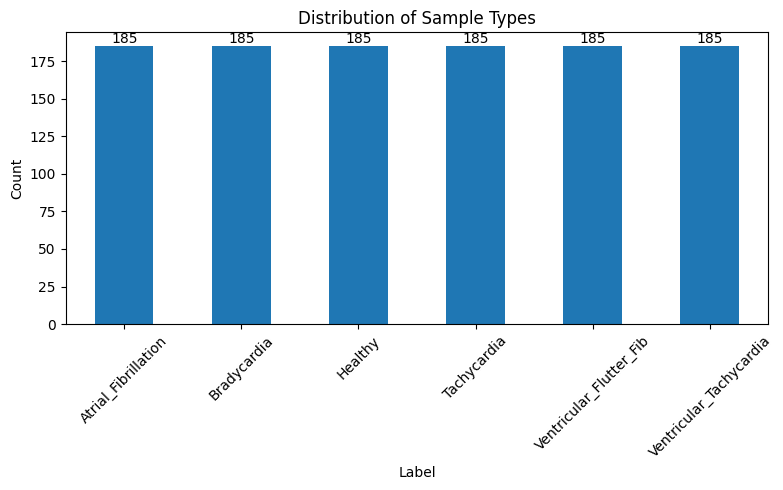


################################################################

STATUS REPORT:
Iteration 1 of 20 runs completed
Test_Score: 0.546, Mean_Score: 0.546, STD: 0.0

################################################################
 

################################################################

STATUS REPORT:
Iteration 2 of 20 runs completed
Test_Score: 0.335, Mean_Score: 0.441, STD: 0.1057066168747812

################################################################
 

################################################################

STATUS REPORT:
Iteration 3 of 20 runs completed
Test_Score: 0.415, Mean_Score: 0.432, STD: 0.08716879653951745

################################################################
 

################################################################

STATUS REPORT:
Iteration 4 of 20 runs completed
Test_Score: 0.388, Mean_Score: 0.421, STD: 0.07781217249578262

################################################################
 

################################

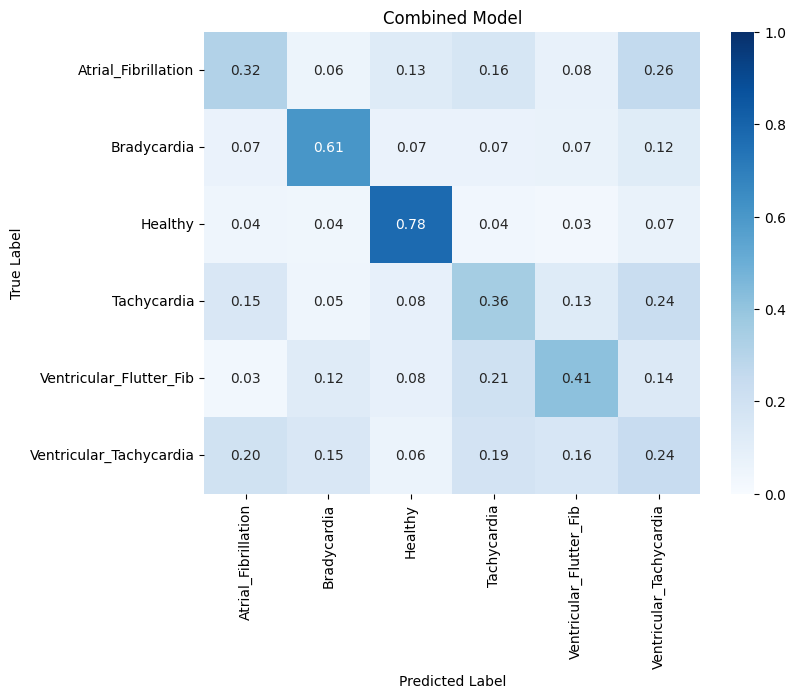

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

max_num_samples=185

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':max_num_samples, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
groups=Xg["Groups"]

# Count the occurrences of each label
label_counts = y.value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()

num_classes=len(samples_df["Labels"].unique())
accumulated_cm=np.zeros((num_classes, num_classes))

scores=[]
num_trials=20

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(X, groups=groups)
    train_inds, test_inds=next(split)

    train_X=X.iloc[train_inds]
    test_X=X.iloc[test_inds]
    train_y=y.iloc[train_inds]
    test_y=y.iloc[test_inds]
    
    model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    model.fit(train_X, train_y)
    yhat=model.predict(test_X)
    acc = accuracy_score(test_y, yhat)
    
    scores.append(acc)

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Mean_Score: {np.mean(scores):.3f}, STD: {np.std(scores)}')
    print("\n################################################################\n ")

    accumulated_cm += confusion_matrix(test_y, yhat, labels=model.classes_)

final_cm = accumulated_cm.astype('float') / accumulated_cm.sum(axis=1, keepdims=True)

# Plot final confusion matrix
#plot_confusion_matrix(y_true=test_y, y_pred=yhat, class_names=model.classes_, normalize=False)
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_, vmin=0, vmax=1)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Combined Model')
plt.show()

In [ ]:
import numpy as np
from sklearn.tree import _tree
from sklearn.ensemble import RandomForestClassifier
import joblib

def tree_to_code(tree, feature_names, tree_index=0, file=None):
    """Recursively converts a decision tree to a set of if-else rules and writes it to a file."""
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
    
    def recurse(node, depth):
        indent = "    " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            file.write(f"{indent}if ({name} <= {threshold}) {{\n")
            recurse(tree_.children_left[node], depth + 1)
            file.write(f"{indent}}} else {{\n")
            recurse(tree_.children_right[node], depth + 1)
            file.write(f"{indent}}}\n")
        else:
            file.write(f"{indent}votes[{tree_index}] = {np.argmax(tree_.value[node])};\n")

    file.write(f"// Decision rules for tree {tree_index}\n")
    recurse(0, 1)

max_num_samples=185

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':max_num_samples, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
X_important=X[high_importance_features]
model = RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7, max_depth=10)
model.fit(X_important, y)

feature_names=""
for feature in model.feature_names_in_:
    feature_names+="float "+feature+", "

feature_names=feature_names[0:-2]

with open("random_forest.cpp", "w") as file:
    file.write("#include <vector>\n")
    file.write("using namespace std;\n\n")
    file.write("int random_forest_predict("+feature_names+") {\n")
    file.write(f"    int votes[{len(model.estimators_)}] = {{0}};\n")
    
    for i, tree in enumerate(model.estimators_):
        #file.write(f"    votes[{i}] = (\n")
        tree_to_code(tree, model.feature_names_in_, tree_index=i, file=file)
        #file.write("    );\n")
    
    file.write("    // Majority voting\n")
    file.write(f"    int class_counts[{model.n_classes_}] = {{0}};\n")
    file.write(f"    for (int i = 0; i < {len(model.estimators_)}; i++) {{\n")
    file.write("        class_counts[votes[i]]++;\n")
    file.write("    }\n")
    file.write("    int predicted_class = 0;\n")
    file.write(f"    for (int i = 1; i < {model.n_classes_}; i++) {{\n")
    file.write("        if (class_counts[i] > class_counts[predicted_class]) {\n")
    file.write("            predicted_class = i;\n")
    file.write("        }\n")
    file.write("    }\n")
    file.write("    return predicted_class;\n")
    file.write("}\n")
